# Lab 2: Data Visualization — Asset Returns

In this lab you will work with daily returns of six **sector indices** on Oslo Børs, covering 2020 to 2025.

🎯 In this lab, you will learn how to:

- Describe a distribution with summary statistics, a box plot and a histogram
- Recognize **fat tails** in real return data, and why they matter for risk
- Plot cumulative returns for several series in a line chart

## Setup

Run the cell below once. It installs any missing packages and loads them.

In [ ]:
# load packages
pkgs <- c("tidyverse", "moments", "data.table", "ggrepel", "knitr", "kableExtra", "IRdisplay", "ggsci")
missing <- setdiff(pkgs, rownames(installed.packages()))
if (length(missing) > 0) install.packages(missing)
invisible(lapply(pkgs, function(pkg) suppressPackageStartupMessages(library(pkg, character.only = TRUE))))

## The Data

In [ ]:
f_url <- "data/NO_6-sector_index_daily.csv"
sector_index <- read_csv(f_url, show_col_types = FALSE)
print(sector_index$sector %>% unique())
# data preview, first and last 5 rows
sector_index %>% as.data.table() %>% print(topn = 5)

### Variable description

The file contains daily returns for **six industry sectors** from 2020 to 2025. It has
**9,396 rows** and four columns. One row is **one sector on one trading day**, and every
sector has all 1,566 trading days — the panel is balanced.

| Column | Type | Description |
|-----|-------|----------------------------|
| `sector` | text | Sector name. Six sectors: `Consumer Non-Cyclicals`, `Energy`, `Finance`, `Industrials`, `Non-Energy Materials`, `Technology`. |
| `p_date` | date | Price date, i.e. the trading day the return refers to. Runs from 2020-01-01 to 2025-12-31. |
| `ret` | numeric | The sector index return **on that day**, as a **decimal**. `0.0001` means the index rose 1 basis point that day. |
| `cum_ret` | numeric | The **cumulative** return of the index from 2020-01-01 up to and including that day, as a decimal. `0.01` means 1 NOK invested at the start would be worth 1.01 NOK. |

## Part 1 — Summary statistics

We will use the helper function to calculate summary statistics for each sector. 

In [12]:
quick_summary <- function(x) {
    data.frame(
        n = length(x), min = min(x), mean = mean(x), median = median(x),
        max = max(x), sd = sd(x),
        skewness = moments::skewness(x), kurtosis = moments::kurtosis(x),
        row.names = NULL
    )
}

### ✍️ Task 1.1 — summary statistics by sector

Produce the summary statistics **for each sector**. 
Note that `min`, `mean`, `median`, `max` and `sd` are expressed in **percent**, while `skewness` and `kurtosis` are **unitless**.

In [77]:
stats_by_sector <- sector_index %>%
    group_by(sector) %>%
    group_modify(~ quick_summary(.x$ret)) %>%
    ungroup() %>%
    mutate(
        across(c(min, mean, median, max, sd), ~ round(.x * 100, 3)),
        across(c(skewness, kurtosis), ~ round(.x, 2))
    )

publish_mimebundle(list(
    "text/html" = as.character(kable(stats_by_sector, format = "html")),
    "text/latex" = as.character(
        kable(
            stats_by_sector, format = "latex", 
            booktabs = TRUE, linesep = ""
        ) %>%
        kable_styling(latex_options = "scale_down")
    )
))


sector,n,min,mean,median,max,sd,skewness,kurtosis
Consumer Non-Cyclicals,1566,-15.313,0.033,0.000,6.593,1.291,-1.23,18.11
Energy,1566,-20.096,0.063,0.009,10.297,1.961,-0.61,11.79
Industrials,1566,-11.417,0.058,0.017,7.249,1.625,-0.51,7.22
Technology,1566,-8.365,0.054,0.029,9.004,1.802,0.01,5.41
Non-Energy Materials,1566,-7.737,0.070,0.036,10.023,1.520,-0.05,5.59
Finance,1566,-11.138,0.069,0.083,7.845,1.308,-0.89,13.71


Q1: Return volatility/risk is often measured as the **standard deviation** of daily returns. Which sector is the **least risky** and which is the **most risky**?

A: [Type your answer here]

**Q2:** By looking at skewness, which sector has the most **asymmetric** distribution of daily returns? By looking at kurtosis, which sector has the **fattest tails**?

A: [Type your answer here]

Q3: Why the least risky sector is not necessarily the one with the thinnest tails?

A: [Type your answer here]

## Part 2 — Show the distribution

Summary statistics compress a distribution into a handful of numbers, and very
different distributions can share the same mean and standard deviation. Always look at
the shape as well.

### ✍️ Task 2.1 — box plot by sector

A box plot shows the median (the line inside the box), the interquartile range (the box
itself, Q1 to Q3), whiskers reaching to the bulk of the data, and individual points for
anything beyond. It is the fastest way to compare several groups side by side.

In [18]:
sector_order <- stats_by_sector %>%
    arrange(median) %>%
    pull(sector)
sector_order
# fix factor order
sector_index <- sector_index %>%
    mutate(sector = factor(sector, levels = sector_order))

[1] "Consumer Non-Cyclicals" "Energy"                 "Industrials"           
[4] "Technology"             "Non-Energy Materials"   "Finance"

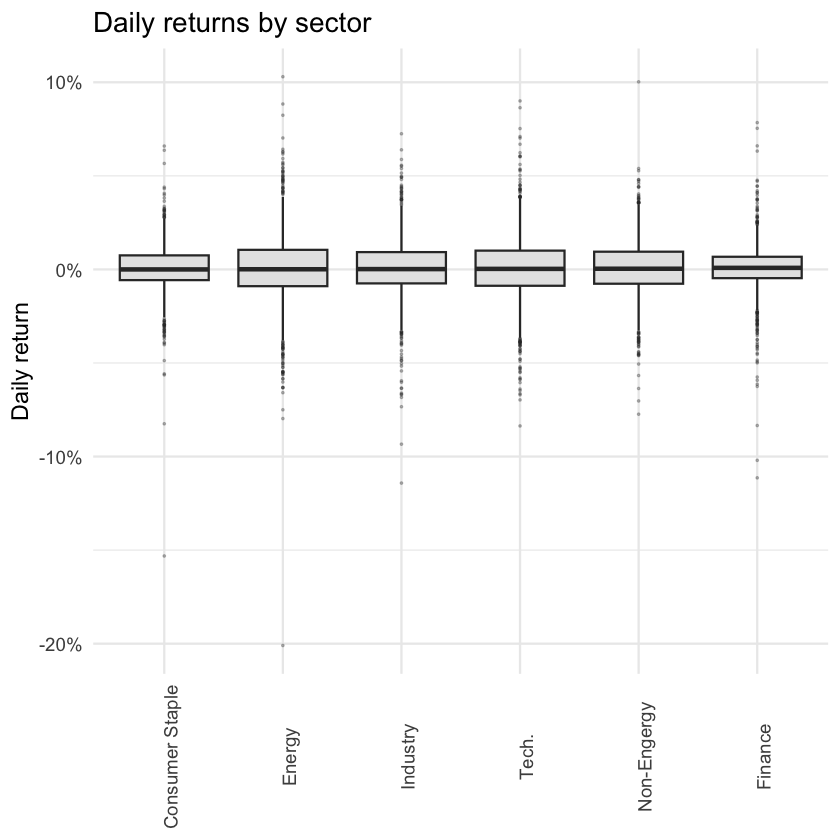

In [68]:
#| fig-dpi: 600
#| out-width: "100%"
#| fig-width: 9
#| fig-height: 12

labels <- setNames(c("Consumer Staple", "Energy", "Industry", "Tech.", "Non-Engergy", "Finance"), sector_order)

ggplot(sector_index, aes(x = sector, y = ret)) +
    geom_boxplot(outlier.size = 0.4, outlier.alpha = 0.3, fill = "grey90") +
    scale_x_discrete(labels = labels) +
    scale_y_continuous(labels = scales::percent) +
    labs(title = "Daily returns by sector", x = NULL, y = "Daily return") +
    theme_minimal(base_size = 14) +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 1, hjust = 0.5)
    )

In [50]:
# Calculate IQR
sector_IQR <- sector_index %>%
    group_by(sector) %>%
    summarise(IQR = IQR(ret)) %>%
    arrange(desc(IQR)) %>%
    left_join(stats_by_sector[c("sector", "sd")], by = "sector")
results <- sector_IQR %>%
    mutate(IQR = scales::percent(IQR, accuracy = 0.02)) %>%
    kable(format = "html")
display_html(as.character(results))

sector,IQR,sd
Energy,1.94%,1.961
Technology,1.88%,1.802
Non-Energy Materials,1.72%,1.520
Industrials,1.68%,1.625
Consumer Non-Cyclicals,1.32%,1.291
Finance,1.14%,1.308


**Q4:** Which sector has the widest box, and which the narrowest? Compare your reading of the plot with the `sd` column from Task 1.1 — do they agree?

A: [Type your answer here]

### ✍️ Task 2.2 — histogram

The box plot compares sectors; a histogram shows the shape of one distribution in
detail. Start with 50 bins.

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


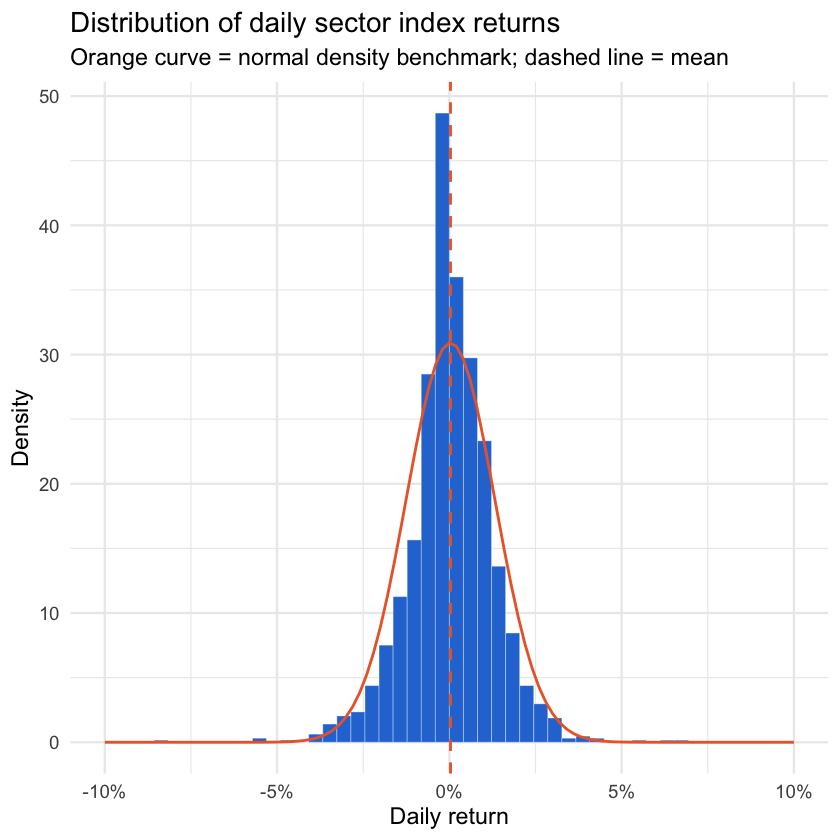

In [ ]:
sector_data <- sector_index %>%
     filter(sector == "Consumer Non-Cyclicals")

ggplot(sector_data, aes(x = ret)) +
     geom_histogram(
          aes(y = after_stat(density)),
          bins = 50,
          fill = "#2a78d6",
          colour = "white",
          linewidth = 0.1
     ) +
     stat_function(
          fun = dnorm,
          args = list(
               mean = mean(sector_data$ret, na.rm = TRUE),
               sd = sd(sector_data$ret, na.rm = TRUE)
          ),
          colour = "#eb6834",
          linewidth = 0.8
     ) +
     scale_x_continuous(limits=c(-0.1,0.1),labels = scales::percent) +
     labs(
          title = "Distribution of daily sector index returns",
          subtitle = "Orange curve = normal density benchmark; dashed line = mean",
          x = "Daily return",
          y = "Density"
     ) +
     theme_minimal(base_size = 14)

### ✍️ Task 2.3 — QQ plot

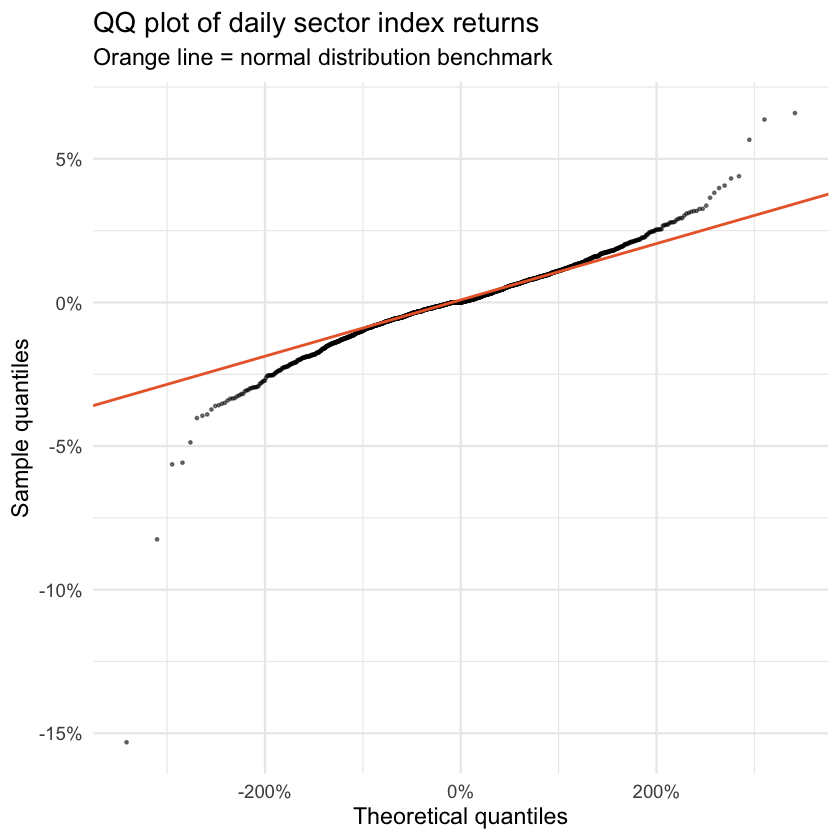

In [62]:
# plot the QQ plot for Consumer Non-Cyclicals
ggplot(sector_data, aes(sample = ret)) +
     stat_qq(size = 0.5, alpha = 0.5) +
     stat_qq_line(colour = "#eb6834", linewidth = 0.8) +
     scale_x_continuous(labels = scales::percent) +
     scale_y_continuous(labels = scales::percent) + 
     labs(
          title = "QQ plot of daily sector index returns",
          subtitle = "Orange line = normal distribution benchmark",
          x = "Theoretical quantiles",
          y = "Sample quantiles"
     ) +
     theme_minimal(base_size = 14)

**Q5:** What can you tell from the QQ plot about the tails of the distribution?

A: [Type your answer here]

## Part 3 — Cumulative return

### How to calculate it

Every return so far has been a **one-day** return. To answer "what would 1 NOK invested on 2020-01-01 be worth today?" you must **compound** the daily returns — you cannot simply add them up.

A return of $r_t$ turns 1 NOK into $(1 + r_t)$ NOK. Over $T$ days you multiply those growth factors together:

$$
1 \;\longrightarrow\; (1+r_1)(1+r_2)\cdots(1+r_T) \;=\; \prod_{t=1}^{T} (1 + r_t)
$$

That product is the **gross** cumulative return — the value of your 1 NOK. Subtract the 1 NOK you started with to get the **net** cumulative return:

$$
\text{Cum}_T \;=\; \prod_{t=1}^{T} (1 + r_t) \; - \; 1
$$

In the dataset, the `cum_ret` column is the **net** cumulative return, expressed as a decimal.

### ✍️ Task 4.1 Plot the cumulative return

Draw one line per sector.

In [74]:
#| fig-dpi: 600
#| out-width: "100%"
#| fig-width: 12
#| fig-height: 9

sector_cols <- setNames(pal_d3()(6), sector_order)
# the last observation of each sector, used to place the labels
ends <- sector_index %>% group_by(sector) %>% slice_tail(n = 1) %>% ungroup()

p <- ggplot(sector_index, aes(x = p_date, y = cum_ret, colour = sector)) +
     geom_hline(yintercept = 0, colour = "grey70", linewidth = 0.3) +
     geom_line(linewidth = 0.6) +
     geom_text_repel(
          data = ends, aes(label = sector), hjust = 0, direction = "y",
          nudge_x = 120, segment.colour = "grey70", size = 4, seed = 1
     ) +
     scale_colour_manual(values = sector_cols) +
     scale_y_continuous(labels = scales::percent) +
     scale_x_date(
          breaks = seq(as.Date("2020-01-01"), as.Date("2025-01-01"), by = "1 year"),
          date_labels = "%Y", expand = expansion(mult = c(0.02, 0.26))
     ) +
     labs(
          title = "Cumulative return of value-weighted sector indices",
          subtitle = "Oslo Børs, 2020-01-01 to 2025-12-31",
          x = NULL, y = "Cumulative return"
     ) +
     theme_minimal(base_size = 14) +
     theme(panel.grid.minor = element_blank(), legend.position = "none")

# Save the plot to a file
f_name <- "images/index_cum_returns_line-chart.png"
if (!dir.exists("images")) dir.create("images")
ggsave(f_name, p, width = 12, height = 6)

![](images/index_cum_returns_line-chart.png){width=100%}

**Q6:** Every sector has one obvious collapse early in the sample. Which sector fell furthest, and what event does the date correspond to? Use the code below to check your reading of the chart against the numbers.

In [66]:
sector_index %>%
    group_by(sector) %>%
    summarise(trough = min(cum_ret), trough_date = p_date[which.min(cum_ret)])

sector,trough,trough_date
<fct>,<dbl>,<date>
Consumer Non-Cyclicals,-0.2170800,2020-03-27
Energy,-0.4993290,2020-03-18
Industrials,-0.2710391,2020-03-23
Technology,-0.3395207,2020-03-18
Non-Energy Materials,-0.2783739,2020-03-18
Finance,-0.3957562,2020-03-18


A: [Type your answer here]